<a href="https://colab.research.google.com/github/Shaulaa/data-mining/blob/main/decision_tree_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes (2).csv


5 data pertama:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72             35        0  33.6                     0.627   50        1
1            1       85             66             29        0  26.6                     0.351   31        0
2            8      183             64              0        0  23.3                     0.672   32        1
3            1       89             66             23       94  28.1                     0.167   21        0
4            0      137             40             35      168  43.1                     2.288   33        1

Akurasi: 79.22%

Confusion Matrix:
                       Prediksi Tidak Diabetes  Prediksi Diabetes
Aktual Tidak Diabetes                       83                 17
Aktual Diabetes                             15                 39

Classification Report:
              precision    recall  f1-score   support

           0     

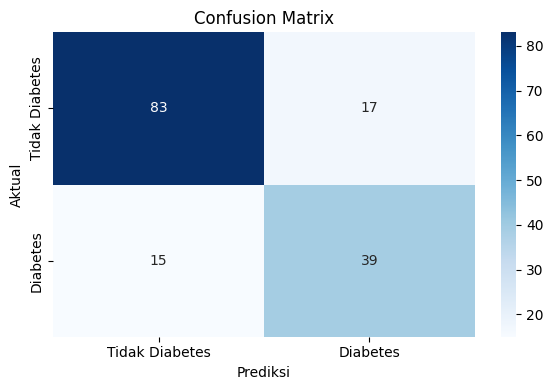

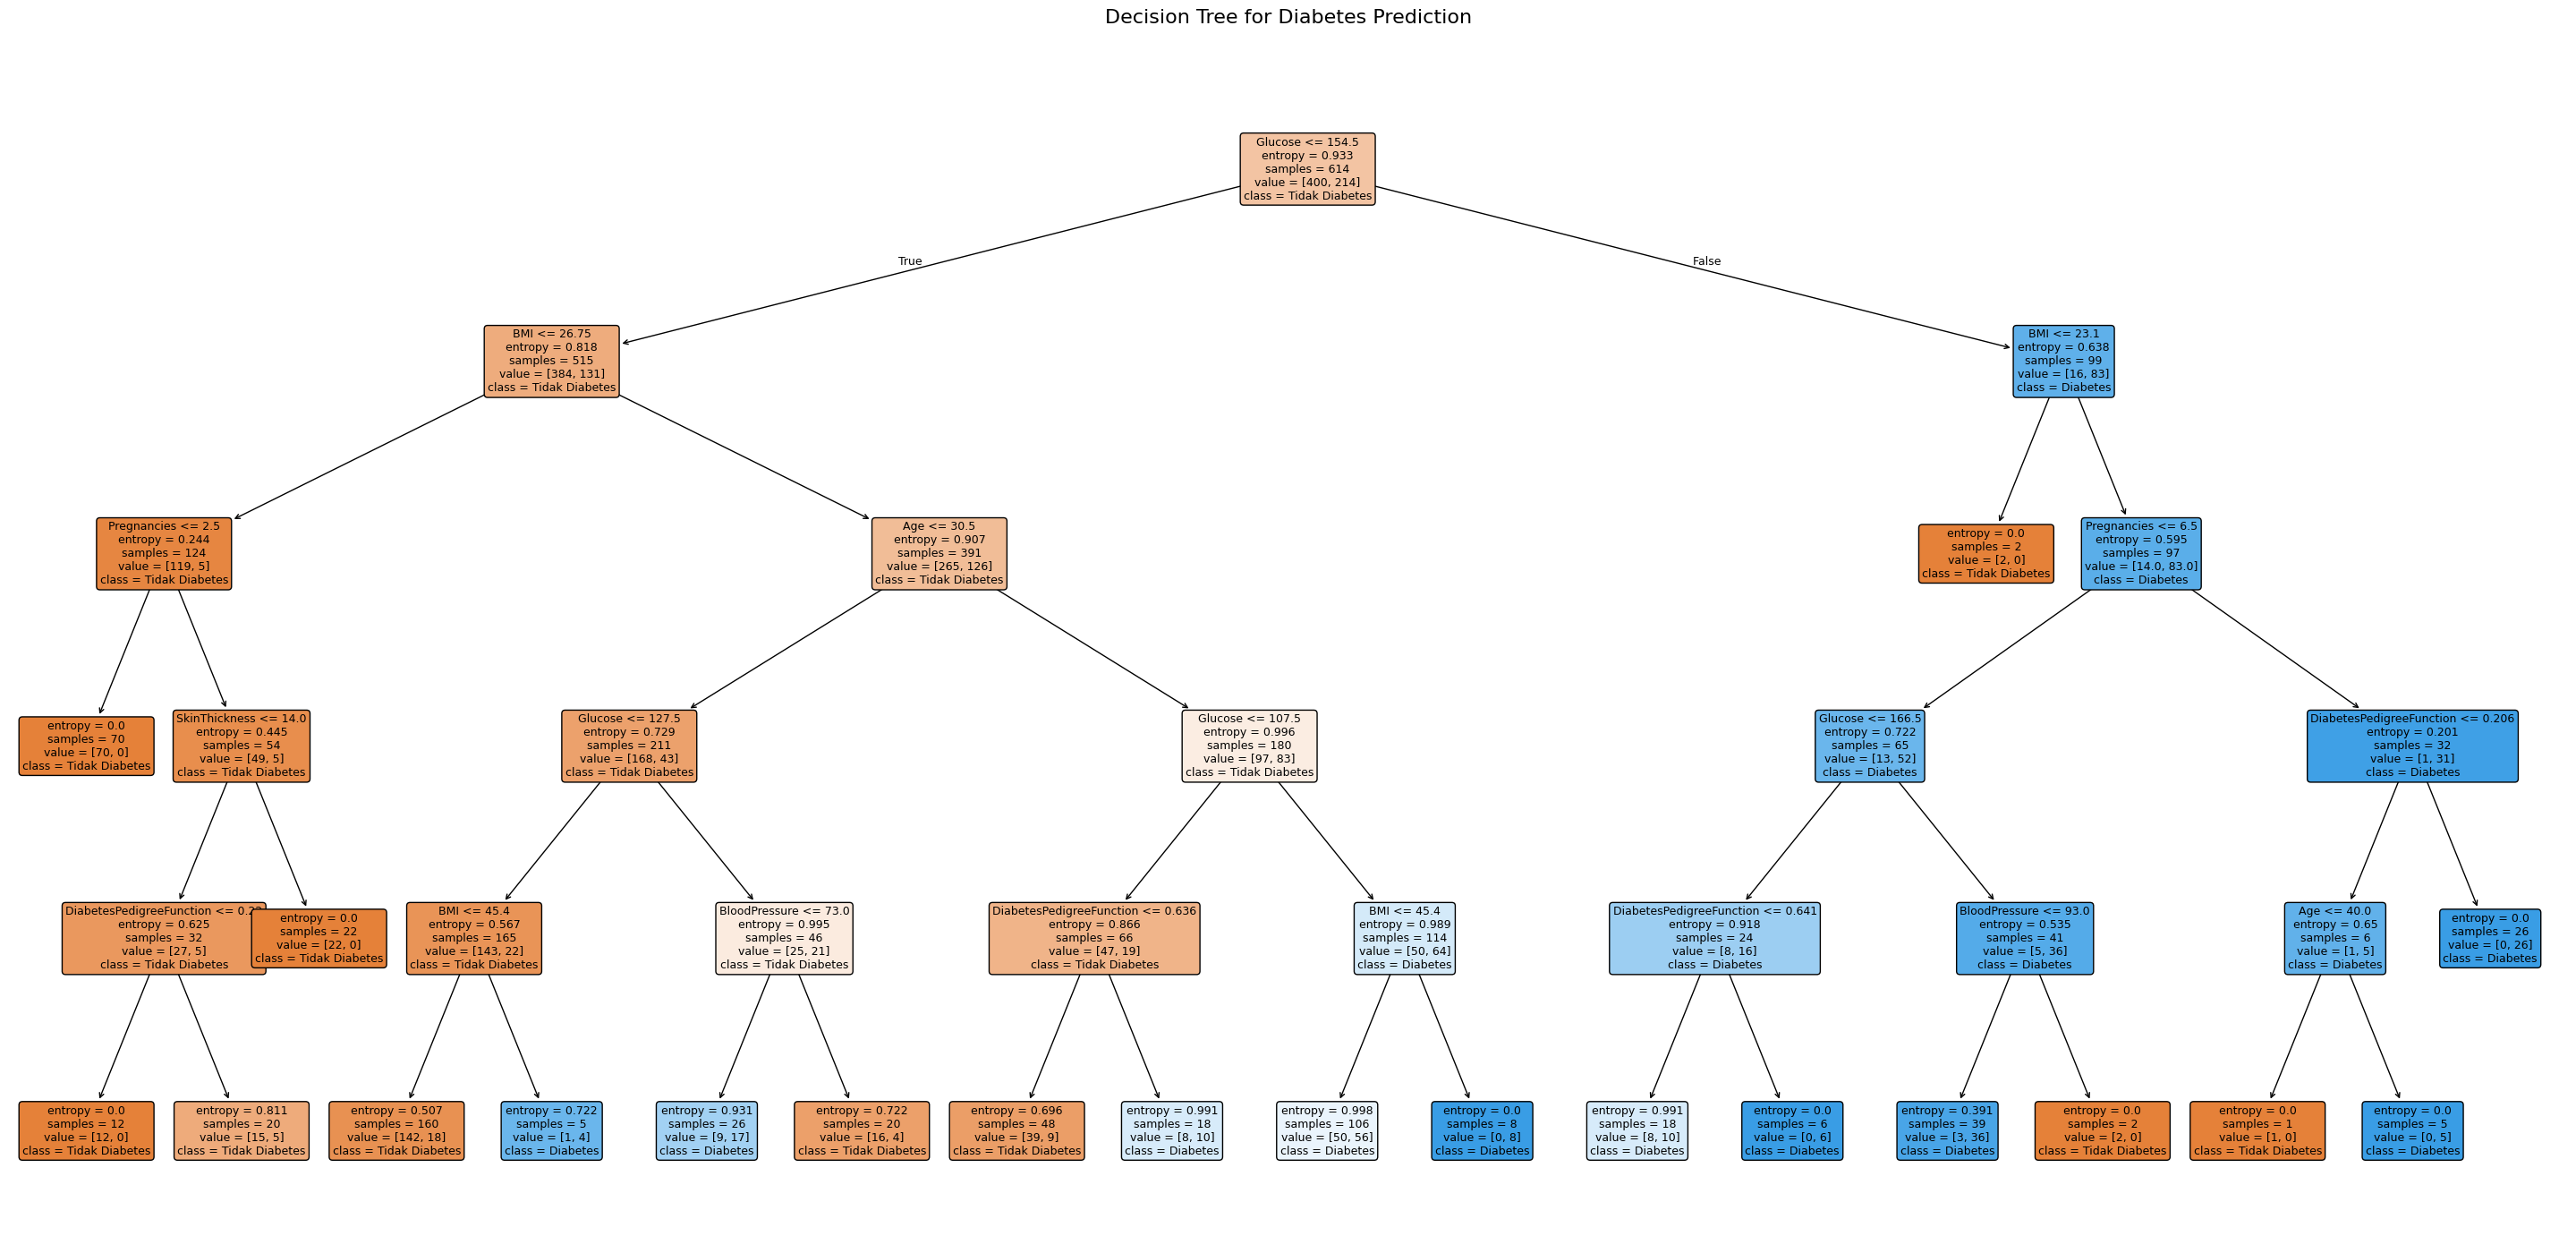

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load dataset
data = pd.read_csv("diabetes.csv")

# Menampilkan 5 data pertama
pd.set_option("display.max_columns", None)

print("5 data pertama:")
print(data.head().to_string())

# Menentukan fitur dan target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Membuat model Decision Tree
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

# Training model
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi akurasi
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAkurasi: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Aktual Tidak Diabetes", "Aktual Diabetes"],
    columns=["Prediksi Tidak Diabetes", "Prediksi Diabetes"]
)

print("\nConfusion Matrix:")
print(cm_df)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importance = pd.DataFrame({
    "Fitur": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Tidak Diabetes", "Diabetes"],
    yticklabels=["Tidak Diabetes", "Diabetes"]
)

plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

# Jarak antar output
print("\n" * 5)

# Visualisasi Decision Tree
plt.figure(figsize=(30, 15))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Tidak Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Decision Tree for Diabetes Prediction",
    fontsize=16,
    pad=40
)

plt.tight_layout(pad=5.0)
plt.show()